# installs & versions

In [ ]:
!pip install catboost xgboost

# Setup: Colab, imports, reproducibility

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error, r2_score,
    mean_squared_error, max_error
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split

from catboost import CatBoostRegressor
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


Mounted at /content/drive


# Loading dataset

In [ ]:

path = "/content/drive/MyDrive/BCU/THESIS/datasets/engineered_metadata.csv"
df_raw = pd.read_csv(path)
df_raw = df_raw[(df_raw["type"] == "discharge") & (df_raw["cycle_duration"].notna())].copy()

features = [
    'avg_voltage','voltage_drop','voltage_gradient','voltage_std',
    'avg_current','max_current','current_std',
    'initial_temp','final_temp','temp_rise',
    'energy_approx','start_voltage','end_voltage'
]
target = "cycle_duration"

df = df_raw[features + [target]].dropna().reset_index(drop=True)

# Cleaning via IQR


In [ ]:
Q1, Q3 = df[target].quantile([0.25, 0.75])
IQR = Q3 - Q1
df_clean = df[(df[target] >= Q1 - 1.5*IQR) & (df[target] <= Q3 + 1.5*IQR)].copy()

print("Original dataset size:", len(df))
print("Clean dataset size:", len(df_clean))


Original dataset size: 2794
Clean dataset size: 2141


# Helper functions (metrics, clipping funtion, persistence, LSTM model)


In [ ]:
def mae_to_accuracy(mae, y_true):
    mean_val = np.mean(y_true)
    return np.nan if mean_val == 0 else 100 - (mae / mean_val) * 100

def clip_predictions(preds, y_train, margin=0.0):
    lo, hi = np.min(y_train) - margin, np.max(y_train) + margin
    return np.clip(preds, lo, hi)

def build_deep_mlp(n_features):
    inp = layers.Input(shape=(n_features,))
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64,  activation='relu')(x)
    out = layers.Dense(1)(x)
    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm_model(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=False)(inp)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1)(x)
    model = models.Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model

def persistence_forecast(y_train, y_test):
    if len(y_test) == 0: return np.array([])
    preds = np.empty_like(y_test, dtype=float)
    preds[0] = y_train[-1] if len(y_train) else y_test[0]
    if len(y_test) > 1: preds[1:] = y_test[:-1]
    return preds

#  Residual boosting


In [ ]:
def residual_boosting(base_model, booster_model, X_train, y_train, X_test):
    base_model.fit(X_train, y_train)
    residuals = y_train - base_model.predict(X_train)
    booster_model.fit(X_train, residuals)
    return base_model.predict(X_test) + booster_model.predict(X_test)


# Evaluating all models


In [ ]:
def evaluate_window_models(X_train, y_train, X_test, y_test):
    preds_normal, preds_clipped = {}, {}

    # Base CatBoost
    cat = CatBoostRegressor(verbose=0, random_state=SEED, depth=6, iterations=1000,
                            l2_leaf_reg=5, learning_rate=0.1)
    cat.fit(X_train, y_train)
    p = cat.predict(X_test)
    preds_normal['CatBoost'] = p
    preds_clipped['CatBoost'] = clip_predictions(p, y_train)

    # XGBoost
    xgb_model = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.05, random_state=SEED,
        n_jobs=-1, subsample=1.0, colsample_bytree=1.0
    )
    xgb_model.fit(X_train, y_train)
    p = xgb_model.predict(X_test)
    preds_normal['XGBoost'] = p
    preds_clipped['XGBoost'] = clip_predictions(p, y_train)

    # Random Forest
    rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
    rf.fit(X_train, y_train)
    p = rf.predict(X_test)
    preds_normal['Random Forest'] = p
    preds_clipped['Random Forest'] = clip_predictions(p, y_train)

    # SVR
    svr = SVR(kernel='rbf', C=100, epsilon=0.1)
    svr.fit(X_train, y_train)
    p = svr.predict(X_test)
    preds_normal['SVR'] = p
    preds_clipped['SVR'] = clip_predictions(p, y_train)

    # Deep MLP
    mlp = build_deep_mlp(X_train.shape[1])
    mlp.fit(X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=50, batch_size=32, verbose=0,
            callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
    p = mlp.predict(X_test, verbose=0).flatten()
    preds_normal['Deep MLP'] = p
    preds_clipped['Deep MLP'] = clip_predictions(p, y_train)

    # LSTM
    X_train_lstm = np.expand_dims(X_train, axis=1)
    X_test_lstm  = np.expand_dims(X_test,  axis=1)
    lstm = build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
    lstm.fit(X_train_lstm, y_train,
             validation_data=(X_test_lstm, y_test),
             epochs=50, batch_size=32, verbose=0,
             callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
    p = lstm.predict(X_test_lstm, verbose=0).flatten()
    preds_normal['LSTM'] = p
    preds_clipped['LSTM'] = clip_predictions(p, y_train)

    # Residual CatBoost
    base_cat = CatBoostRegressor(verbose=0, random_state=SEED,
                                 depth=6, iterations=600, learning_rate=0.1, l2_leaf_reg=5)
    booster_cat = CatBoostRegressor(verbose=0, random_state=SEED,
                                    depth=4, iterations=400, learning_rate=0.05, l2_leaf_reg=5)
    p = residual_boosting(base_cat, booster_cat, X_train, y_train, X_test)
    preds_normal['CatBoost + Residual'] = p
    preds_clipped['CatBoost + Residual'] = clip_predictions(p, y_train)

    # Residual Random Forest
    base_rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
    booster_rf = RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=-1)
    p = residual_boosting(base_rf, booster_rf, X_train, y_train, X_test)
    preds_normal['Random Forest + Residual'] = p
    preds_clipped['Random Forest + Residual'] = clip_predictions(p, y_train)

    return preds_normal, preds_clipped

# CatBoost Time-Series Tuning & Rolling-Window Evaluation

In [ ]:
def tune_catboost_timeseries(X_train, y_train,
                             depths=(4,6), l2_regs=(3,5), lrs=(0.03,0.06,0.1),
                             iterations=2000, val_frac=0.15, random_state=SEED):
    n = len(X_train); n_val = max(1, int(n*val_frac))
    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]
    best, best_mae = None, float("inf")
    for d in depths:
        for l2 in l2_regs:
            for lr in lrs:
                m = CatBoostRegressor(depth=d, l2_leaf_reg=l2, learning_rate=lr,
                                      iterations=iterations, loss_function="RMSE",
                                      random_seed=random_state, verbose=False)
                m.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                      use_best_model=True, early_stopping_rounds=200, verbose=False)
                mae = mean_absolute_error(y_val, m.predict(X_val))
                if mae < best_mae:
                    best_mae = mae
                    best = dict(depth=d, l2_leaf_reg=l2, learning_rate=lr,
                                iterations=int(m.tree_count_))
    return best or dict(depth=6, l2_leaf_reg=5, learning_rate=0.06, iterations=1500)

def predict_catboost_tuned_per_window(X_train, y_train, X_test):
    bp = tune_catboost_timeseries(X_train, y_train)
    m = CatBoostRegressor(depth=bp["depth"], l2_leaf_reg=bp["l2_leaf_reg"],
                          learning_rate=bp["learning_rate"], iterations=bp["iterations"],
                          loss_function="RMSE", random_seed=SEED, verbose=False)
    m.fit(X_train, y_train, verbose=False)
    return m.predict(X_test)

def add_metrics_rows(out_rows, eval_label, clip_label, y_true, pred_dict, training_data_label):
    for model_name, preds in pred_dict.items():
        mae = mean_absolute_error(y_true, preds)
        out_rows.append({
            "Training Data": training_data_label,
            "Model": model_name,
            "Eval": eval_label,
            "Clip": clip_label,
            "MAE": mae,
            "MAPE (%)": mean_absolute_percentage_error(y_true, preds) * 100,
            "R²": r2_score(y_true, preds),
            "RMSE": mean_squared_error(y_true, preds) ** 0.5,
            "Max Error": max_error(y_true, preds),
            "Accuracy (%)": mae_to_accuracy(mae, y_true)
        })

def run_eval_on_dataset(df_in, features, target, training_data_label,
                        train_size=500, test_size=100, step=100):
    rows = []
    model_names = [
        'Persistence','CatBoost','XGBoost','Random Forest','SVR',
        'Deep MLP','LSTM','CatBoost (Tuned)',
        'CatBoost + Residual','Random Forest + Residual'
    ]
    rolling_results_normal = {m: [] for m in model_names}
    rolling_results_clipped = {m: [] for m in model_names}
    rolling_true = []

    n = len(df_in)
    for start in range(0, n - train_size - test_size + 1, step):
        train = df_in.iloc[start : start + train_size]
        test  = df_in.iloc[start + train_size : start + train_size + test_size]
        X_train, y_train = train[features].values, train[target].values
        X_test,  y_test  = test[features].values,  test[target].values

        preds_norm, preds_clip = evaluate_window_models(X_train, y_train, X_test, y_test)
        p_tuned = predict_catboost_tuned_per_window(X_train, y_train, X_test)
        preds_norm['CatBoost (Tuned)'] = p_tuned
        preds_clip['CatBoost (Tuned)'] = clip_predictions(p_tuned, y_train)

        p_pers = persistence_forecast(y_train, y_test)
        preds_norm['Persistence'] = p_pers
        preds_clip['Persistence'] = clip_predictions(p_pers, y_train)

        rolling_true.append(y_test)
        for k in model_names:
            if k in preds_norm:
                rolling_results_normal[k].append(preds_norm[k])
                rolling_results_clipped[k].append(preds_clip[k])

    if rolling_true:
        all_true = np.concatenate(rolling_true)
        for model in model_names:
            if rolling_results_normal[model]:
                add_metrics_rows(rows, "Rolling", "Normal",  all_true,
                                 {model: np.concatenate(rolling_results_normal[model])},
                                 training_data_label)
                add_metrics_rows(rows, "Rolling", "Clipped", all_true,
                                 {model: np.concatenate(rolling_results_clipped[model])},
                                 training_data_label)

    # Static 80/20
    cut = int(len(df_in) * 0.8)
    train_s, test_s = df_in.iloc[:cut], df_in.iloc[cut:]
    X_train_s, y_train_s = train_s[features].values, train_s[target].values
    X_test_s,  y_test_s  = test_s[features].values,  test_s[target].values

    static_norm, static_clip = evaluate_window_models(X_train_s, y_train_s, X_test_s, y_test_s)
    p_tuned_static = predict_catboost_tuned_per_window(X_train_s, y_train_s, X_test_s)
    static_norm['CatBoost (Tuned)'] = p_tuned_static
    static_clip['CatBoost (Tuned)'] = clip_predictions(p_tuned_static, y_train_s)

    p_pers_static = persistence_forecast(y_train_s, y_test_s)
    static_norm['Persistence'] = p_pers_static
    static_clip['Persistence'] = clip_predictions(p_pers_static, y_train_s)

    add_metrics_rows(rows, "Static 80/20", "Normal",  y_test_s, static_norm, training_data_label)
    add_metrics_rows(rows, "Static 80/20", "Clipped", y_test_s, static_clip, training_data_label)
    return rows




# Running our code

In [ ]:
# Original vs Cleaned datasets

rows_original = run_eval_on_dataset(df,       features, target, training_data_label="Original")
rows_cleaned  = run_eval_on_dataset(df_clean, features, target, training_data_label="Cleaned")

# Merging dataframes
summary_df = pd.DataFrame(rows_original + rows_cleaned).round(3)
summary_df = summary_df[[
    "Training Data","Model","Eval","Clip","MAE","MAPE (%)","R²","RMSE","Max Error","Accuracy (%)"
]]
# Sorting dataframe by MAE
summary_sorted = summary_df.sort_values(["Eval","Training Data","Clip","MAE"]).reset_index(drop=True)

print("📊 Full Results with Residual Ensembles:")
display(summary_sorted)

print("\n🔎 Clipped-only view, sorted by MAE:")
display(summary_sorted[summary_sorted["Clip"]=="Clipped"]
        .sort_values(["Eval","Training Data","MAE"])
        .reset_index(drop=True))

📊 Full Results with Residual Ensembles:


,Training Data,Model,Eval,Clip,MAE,MAPE (%),R²,RMSE,Max Error,Accuracy (%)
0,Cleaned,Persistence,Rolling,Clipped,64.172,2.494,0.782,228.758,1981.374,97.743
1,Cleaned,Random Forest + Residual,Rolling,Clipped,151.218,5.773,0.742,248.625,2890.576,94.682
2,Cleaned,Random Forest,Rolling,Clipped,152.000,5.862,0.728,255.127,2883.371,94.654
3,Cleaned,CatBoost,Rolling,Clipped,165.758,6.423,0.706,265.351,2904.312,94.170
4,Cleaned,CatBoost + Residual,Rolling,Clipped,165.919,6.427,0.706,265.499,2903.417,94.165
...,...,...,...,...,...,...,...,...,...,...
75,Original,Random Forest + Residual,Static 80/20,Normal,254.019,44.692,0.044,330.831,2263.192,90.409
76,Original,Random Forest,Static 80/20,Normal,266.931,45.764,-0.050,346.747,2312.730,89.921
77,Original,Deep MLP,Static 80/20,Normal,350.950,12.432,-1.441,528.551,1677.716,86.749
78,Original,SVR,Static 80/20,Normal,464.756,32.059,-1.262,508.800,880.888,82.452



🔎 Clipped-only view, sorted by MAE:


,Training Data,Model,Eval,Clip,MAE,MAPE (%),R²,RMSE,Max Error,Accuracy (%)
0,Cleaned,Persistence,Rolling,Clipped,64.172,2.494,0.782,228.758,1981.374,97.743
1,Cleaned,Random Forest + Residual,Rolling,Clipped,151.218,5.773,0.742,248.625,2890.576,94.682
2,Cleaned,Random Forest,Rolling,Clipped,152.000,5.862,0.728,255.127,2883.371,94.654
3,Cleaned,CatBoost,Rolling,Clipped,165.758,6.423,0.706,265.351,2904.312,94.170
4,Cleaned,CatBoost + Residual,Rolling,Clipped,165.919,6.427,0.706,265.499,2903.417,94.165
5,Cleaned,XGBoost,Rolling,Clipped,190.370,6.928,0.514,341.380,2907.591,93.305
6,Cleaned,CatBoost (Tuned),Rolling,Clipped,191.986,7.551,0.607,306.893,2815.746,93.248
7,Cleaned,SVR,Rolling,Clipped,275.327,12.708,0.034,481.058,1950.095,90.317
8,Cleaned,Deep MLP,Rolling,Clipped,365.847,15.176,-0.449,589.223,3184.921,87.133
9,Cleaned,LSTM,Rolling,Clipped,1145.612,37.572,-6.605,1349.811,3184.921,59.710


# Plots

In [ ]:
def plot_metric(df_in, metric="MAE", eval_filter=None, clip_filter=None, top_n=None):
    """
    Grouped bar chart: Original vs Cleaned for the chosen metric.
    You can filter by Eval (e.g., 'Rolling' or 'Static 80/20') and/or Clip ('Normal' or 'Clipped').
    """
    d = df_in.copy()
    if eval_filter is not None:
        d = d[d["Eval"] == eval_filter]
    if clip_filter is not None:
        d = d[d["Clip"] == clip_filter]

    # pivot to columns = Training Data
    pv = d.pivot_table(index=["Model","Eval","Clip"], columns="Training Data", values=metric)
    pv = pv.sort_values(by=list(pv.columns), ascending=True)

    if top_n is not None and top_n < len(pv):
        pv = pv.head(top_n)

    ax = pv.plot(kind="bar", figsize=(14,6), rot=45, title=f"{metric} - Original vs Cleaned"
                 + (f" | Eval={eval_filter}" if eval_filter else "")
                 + (f" | Clip={clip_filter}" if clip_filter else ""))
    ax.set_ylabel(metric)
    ax.legend(title="Training Data")
    plt.tight_layout()
    plt.show()

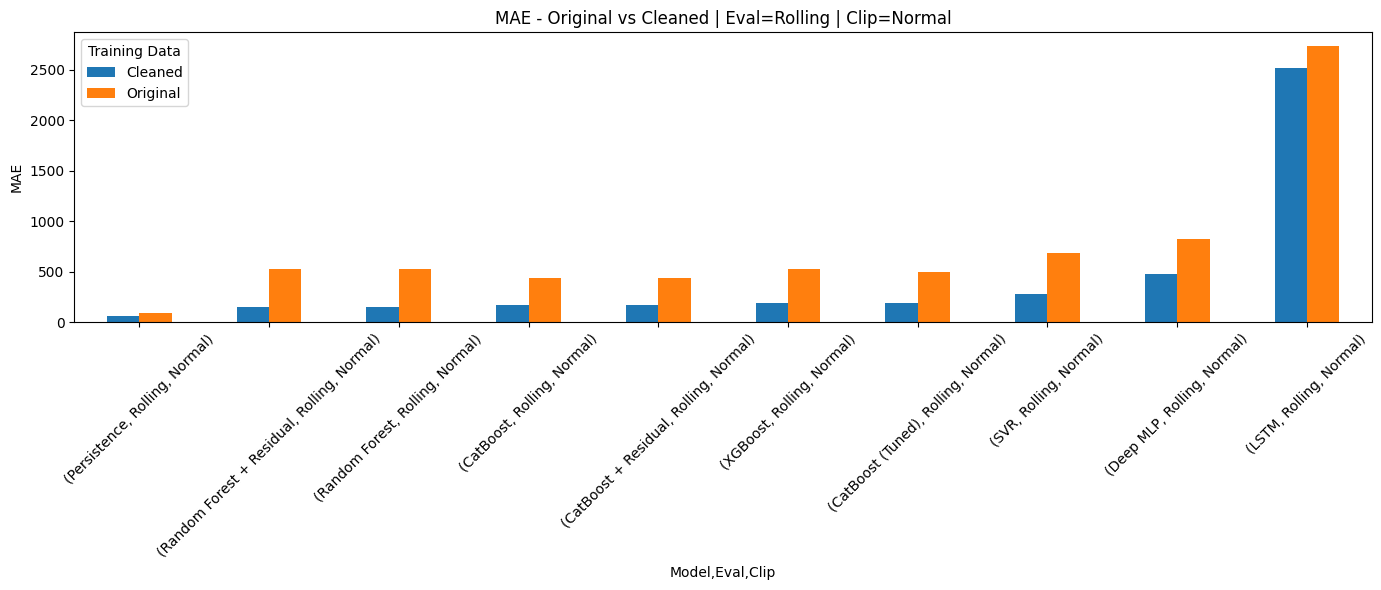

In [ ]:
plot_metric(summary_df, metric="MAE", eval_filter="Rolling", clip_filter="Normal")

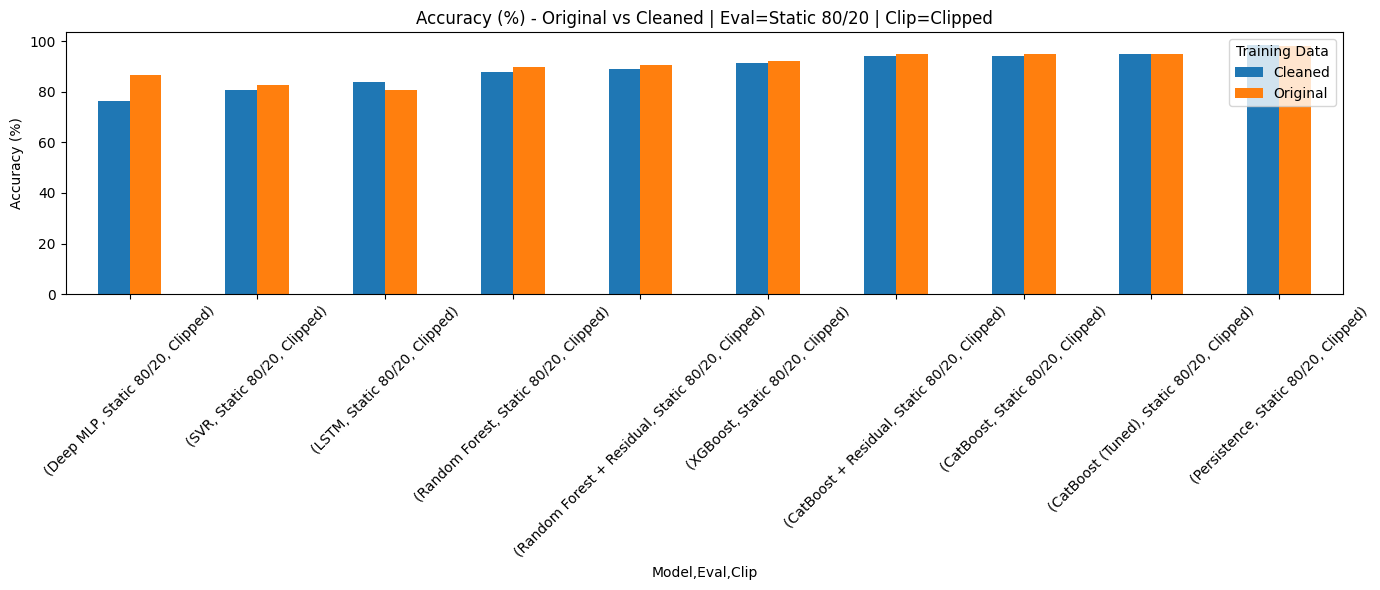

In [ ]:
plot_metric(summary_df, metric="Accuracy (%)", eval_filter="Static 80/20", clip_filter="Clipped")

# Downloading Results

In [ ]:
# download summary_df
from google.colab import files
summary_df.to_csv('summary_df.csv', index=False)
files.download('summary_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Figure 5: Mean Δ per Eval

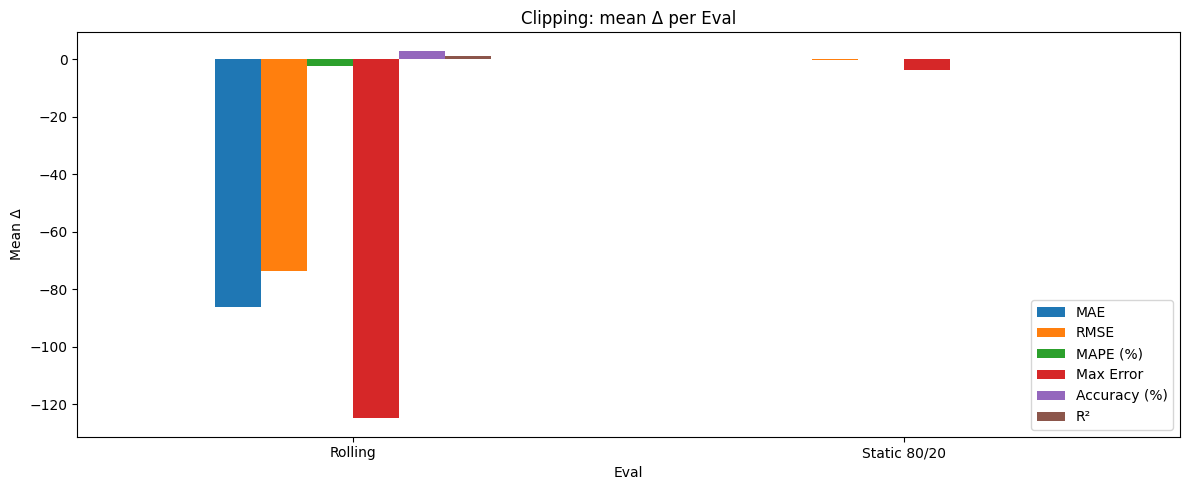

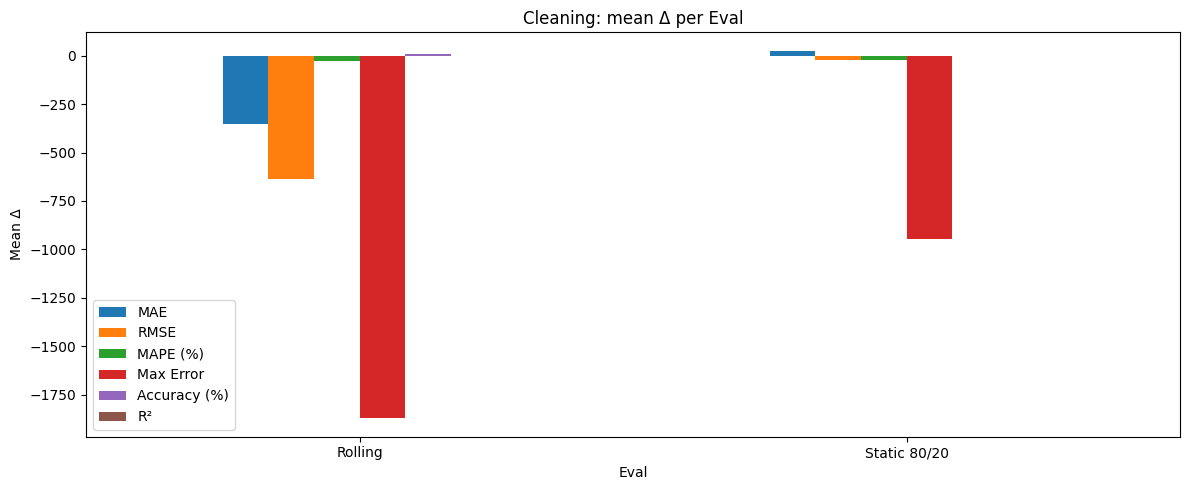

In [ ]:
def plot_mean_delta_per_eval(delta_df, title):
    m = delta_df.groupby("Eval")[["MAE","RMSE","MAPE (%)","Max Error","Accuracy (%)","R²"]].mean().sort_index()
    ax = m.plot(kind="bar", figsize=(12,5), rot=0, title=title)
    ax.set_ylabel("Mean Δ"); plt.tight_layout(); plt.show()

plot_mean_delta_per_eval(delta_clip,  "Clipping: mean Δ per Eval")
plot_mean_delta_per_eval(delta_clean, "Cleaning: mean Δ per Eval")


# Tail risk (Max Error) reduction

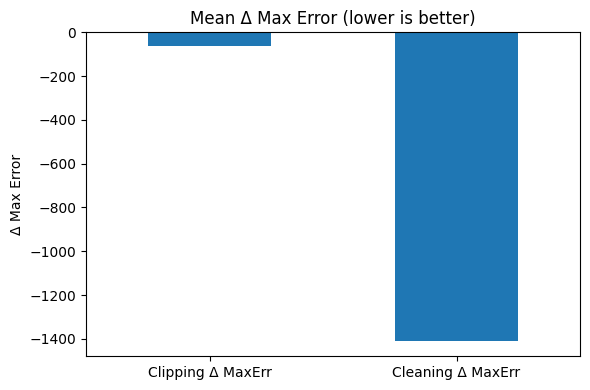

In [ ]:
def plot_tail_reduction(delta_clip, delta_clean):
    import pandas as pd, matplotlib.pyplot as plt
    s = pd.DataFrame({
        "Clipping Δ MaxErr": [delta_clip["Max Error"].mean()],
        "Cleaning Δ MaxErr": [delta_clean["Max Error"].mean()]
    }).T
    ax = s.plot(kind="bar", legend=False, figsize=(6,4), rot=0,
                title="Mean Δ Max Error (lower is better)")
    ax.set_ylabel("Δ Max Error"); plt.tight_layout(); plt.show()

plot_tail_reduction(delta_clip, delta_clean)


# Rolling window expirement

In [ ]:
def rolling_splits(df_in, train_size, test_size, step):
    """Yield (train_idx, test_idx) for fixed-size rolling windows."""
    n = len(df_in)
    for start in range(0, n - train_size - test_size + 1, step):
        tr = slice(start, start + train_size)
        te = slice(start + train_size, start + train_size + test_size)
        yield tr, te

def expanding_splits(df_in, min_train, test_size, step):
    """Yield (train_idx, test_idx) for expanding-origin windows."""
    n = len(df_in)
    start = 0
    while start + min_train + test_size <= n:
        tr = slice(start, start + min_train)
        te = slice(start + min_train, start + min_train + test_size)
        yield tr, te
        min_train += step

def evaluate_config(df_in, features, target, scheme, train_size, test_size, step):
    """
    scheme: 'rolling' or 'expanding'
    Returns per-window metrics (list of dicts) for each model, Normal & Clipped.
    Relies on your `evaluate_window_models` to produce predictions for all models.
    """
    rows = []
    splitter = (rolling_splits if scheme == "rolling" else expanding_splits)
    for w, (tr, te) in enumerate(splitter(df_in, train_size, test_size, step)):
        train = df_in.iloc[tr]
        test  = df_in.iloc[te]
        X_tr, y_tr = train[features].values, train[target].values
        X_te, y_te = test[features].values,  test[target].values

        preds_norm, preds_clip = evaluate_window_models(X_tr, y_tr, X_te, y_te)

        from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error, max_error
        def row_for(model, clip_label, preds):
            mae = mean_absolute_error(y_te, preds)
            return {
                "scheme": scheme,
                "train_size": train_size,
                "test_size": test_size,
                "step": step,
                "window": w,
                "model": model,
                "clip": clip_label,
                "MAE": mae,
                "RMSE": mean_squared_error(y_te, preds)**0.5,
                "MAPE (%)": mean_absolute_percentage_error(y_te, preds)*100,
                "R²": r2_score(y_te, preds),
                "Max Error": max_error(y_te, preds)
            }
        for m, p in preds_norm.items():
            rows.append(row_for(m, "Normal", p))
        for m, p in preds_clip.items():
            rows.append(row_for(m, "Clipped", p))
    return pd.DataFrame(rows)

def sweep_window_sizes(
    df_in, features, target,
    configs = (
        ("rolling",   300, 100, 100),
        ("rolling",   500, 100, 100),
        ("rolling",   700, 100, 100),
        ("rolling",   500,  50,  50),
        ("expanding", 300, 100, 100),
        ("expanding", 500, 100, 100),
    ),
    min_windows=4
):
    """
    Runs a small grid and returns:
      - per_window: long DF of per-window metrics
      - summary: mean & std per (scheme, train_size, test_size, step, model, clip)
      - ranking: sorted by mean MAE then MAE std (stability)
    """
    all_windows = []
    for scheme, tr, te, st in configs:
        df_w = evaluate_config(df_in, features, target, scheme, tr, te, st)
        if df_w["window"].nunique() >= min_windows:
            all_windows.append(df_w)

    if not all_windows:
        raise ValueError("No configs produced enough windows. Try lowering min_windows or sizes.")

    per_window = pd.concat(all_windows, ignore_index=True)

    agg = (per_window
           .groupby(["scheme","train_size","test_size","step","model","clip"])
           .agg(MAE_mean=("MAE","mean"),
                MAE_std =("MAE","std"),
                RMSE_mean=("RMSE","mean"),
                MaxErr_mean=("Max Error","mean"),
                R2_mean=("R²","mean"),
                MAPE_mean=("MAPE (%)","mean"),
                n_windows=("window","nunique"))
           .reset_index())

    ranking = (agg.sort_values(["MAE_mean","MAE_std"])
                  .reset_index(drop=True))

    return per_window, agg, ranking

per_window, agg_summary, ranking = sweep_window_sizes(df_clean, features, target)

top_clipped = (ranking[ranking["clip"]=="Clipped"]
               .groupby("model", as_index=False)
               .first())

print("Top configs by model (preferring lower MAE_mean then lower MAE_std):")
display(top_clipped)

def plot_mae_vs_window(agg_summary, model, scheme=None):
    d = agg_summary[(agg_summary["model"]==model) & (agg_summary["clip"]=="Clipped")]
    if scheme:
        d = d[d["scheme"]==scheme]
    d = d.assign(label = d.apply(lambda r: f"{r['scheme']} {r['train_size']}/{r['test_size']} (step={int(r['step'])})", axis=1))
    d = d.sort_values(["scheme","train_size","test_size","step"])
    plt.figure(figsize=(10,4))
    plt.plot(d["label"], d["MAE_mean"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean MAE across windows")
    title = f"{model}: Mean MAE vs Window config (Clipped)"
    if scheme: title += f" — {scheme}"
    plt.title(title)
    plt.tight_layout()
    plt.show()

for m in ["CatBoost","XGBoost"]:
    plot_mae_vs_window(agg_summary, m)

def plot_bias_variance_tradeoff(agg_summary, model):
    d = agg_summary[(agg_summary["model"]==model) & (agg_summary["clip"]=="Clipped")]
    plt.figure(figsize=(6,6))
    for _, r in d.iterrows():
        label = f"{r['scheme']} {int(r['train_size'])}/{int(r['test_size'])} s{int(r['step'])}"
        plt.scatter(r["MAE_mean"], r["MAE_std"])
        plt.text(r["MAE_mean"], r["MAE_std"], label, fontsize=8)
    plt.xlabel("Mean MAE ↓")
    plt.ylabel("MAE Std ↓ (stability)")
    plt.title(f"{model}: Accuracy–Stability tradeoff across window configs")
    plt.tight_layout()
    plt.show()

plot_bias_variance_tradeoff(agg_summary, "CatBoost")
